In [2]:
# 1. 라이브러리 import
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [3]:
# 2. 데이터 불러오기
df = pd.read_csv("korean_ecommerce_outbound_2022_2025_with_categories.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df

,date,is_weekend,is_holiday,event,promo,prev_qty,avg7_qty,food_qty,drink_qty,daily_qty,...,beauty_qty,avg7_food_qty,avg7_drink_qty,avg7_daily_qty,avg7_cold_qty,avg7_beauty_qty,top_sku_ratio,heavy_item_ratio,cold_chain_ratio,outbound_qty
0,2022-01-01,1,1,0,0,311,311.0,96,73,49,...,29,96.0,73.0,49.0,64.0,29.0,0.170,0.183,0.203,311
1,2022-01-02,1,0,0,0,311,311.0,92,60,49,...,22,96.0,73.0,49.0,64.0,29.0,0.193,0.179,0.132,283
2,2022-01-03,0,0,0,0,283,297.0,100,91,68,...,53,94.0,66.5,49.0,62.0,25.5,0.182,0.175,0.205,369
3,2022-01-04,0,0,0,0,369,321.0,98,78,80,...,37,96.0,74.7,55.3,60.3,34.7,0.188,0.192,0.235,351
4,2022-01-05,0,0,0,0,351,328.5,109,76,67,...,43,96.5,75.5,61.5,59.8,35.2,0.146,0.177,0.229,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2025-12-27,1,0,0,0,729,675.7,171,91,106,...,60,235.3,118.9,170.7,50.3,100.6,0.182,0.153,0.151,504
1457,2025-12-28,1,0,0,0,504,681.0,147,78,91,...,52,237.0,119.9,171.9,51.1,101.1,0.203,0.143,0.150,433
1458,2025-12-29,0,0,0,0,433,689.1,204,114,152,...,95,239.7,121.3,173.6,52.4,102.1,0.139,0.147,0.110,635
1459,2025-12-30,0,0,0,0,635,658.4,197,111,148,...,92,224.0,112.0,163.7,57.6,101.1,0.156,0.164,0.110,616


In [4]:
# 3. date에서 파생 컬럼 생성
df["weekday_num"] = df["date"].dt.weekday
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [5]:
features = [
    "weekday_num",
    "month",
    "day",
    "is_weekend",
    "is_holiday",
    "event",
    "promo",
    "prev_qty",
    "avg7_qty",
    "avg7_food_qty",
    "avg7_drink_qty",
    "avg7_daily_qty",
    "avg7_cold_qty",
    "avg7_beauty_qty",
    "top_sku_ratio",
    "heavy_item_ratio",
    "cold_chain_ratio"
]
target = "outbound_qty"

In [6]:
print(type(features))
print(features)

<class 'list'>
['weekday_num', 'month', 'day', 'is_weekend', 'is_holiday', 'event', 'promo', 'prev_qty', 'avg7_qty', 'avg7_food_qty', 'avg7_drink_qty', 'avg7_daily_qty', 'avg7_cold_qty', 'avg7_beauty_qty', 'top_sku_ratio', 'heavy_item_ratio', 'cold_chain_ratio']


In [7]:
split_idx = int(len(df) * 0.8)

X_train = df[features].iloc[:split_idx]
X_test = df[features].iloc[split_idx:]

y_train = df[target].iloc[:split_idx]
y_test = df[target].iloc[split_idx:]


In [8]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [9]:
def create_seq(X, y, window_size=14):
    xs, ys = [], []
    for i in range(len(X) - window_size):
        xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(xs), np.array(ys)

window_size = 14

X_train_seq, y_train_seq = create_seq(X_train_scaled, y_train_scaled, window_size)
X_test_seq, y_test_seq = create_seq(X_test_scaled, y_test_scaled, window_size)


In [10]:
class OutboundDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [11]:
class OutboundLSTM(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


In [12]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [13]:
train_dataset = OutboundDataset(X_train_seq, y_train_seq)
test_dataset = OutboundDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(X_train_seq.shape, y_train_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(1154, 14, 17) (1154, 1)
(279, 14, 17) (279, 1)


In [14]:
input_dim = X_train_seq.shape[2]

model = OutboundLSTM(input_dim).to(device)

mseloss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model

OutboundLSTM(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [15]:
num_epochs = 200
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for b_x, b_y in train_loader:
        b_x = b_x.to(device)
        b_y = b_y.to(device)

        optimizer.zero_grad()
        pred = model(b_x)
        loss = mseloss(pred, b_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * b_x.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}")


Epoch [20/200] Loss: 0.442117
Epoch [40/200] Loss: 0.269326
Epoch [60/200] Loss: 0.166374
Epoch [80/200] Loss: 0.102452
Epoch [100/200] Loss: 0.048999
Epoch [120/200] Loss: 0.044364
Epoch [140/200] Loss: 0.027788
Epoch [160/200] Loss: 0.023740
Epoch [180/200] Loss: 0.018635
Epoch [200/200] Loss: 0.017343


In [16]:
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for b_x, b_y in test_loader:
        b_x = b_x.to(device)

        pred = model(b_x).cpu().numpy()
        preds.append(pred)
        actuals.append(b_y.numpy())

pred_scaled = np.vstack(preds)
y_scaled = np.vstack(actuals)

pred_real = scaler_y.inverse_transform(pred_scaled)
y_real = scaler_y.inverse_transform(y_scaled)

pred_real[:5], y_real[:5]


(array([[513.9734 ],
        [451.7046 ],
        [421.07904],
        [440.11014],
        [506.05252]], dtype=float32),
 array([[537.],
        [533.],
        [366.],
        [554.],
        [481.]], dtype=float32))

In [17]:
mae = np.mean(np.abs(y_real - pred_real))
rmse = np.sqrt(np.mean((y_real - pred_real) ** 2))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 83.65
RMSE: 113.00


In [18]:
X_all_scaled = scaler_X.transform(df[features])

last_seq = X_all_scaled[-window_size:]
last_seq_tensor = torch.tensor(last_seq, dtype=torch.float32).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    tomorrow_scaled = model(last_seq_tensor).cpu().numpy()

tomorrow_qty = scaler_y.inverse_transform(tomorrow_scaled)[0][0]

print(f"내일 예상 출고량: {tomorrow_qty:.0f} 건")


내일 예상 출고량: 651 건


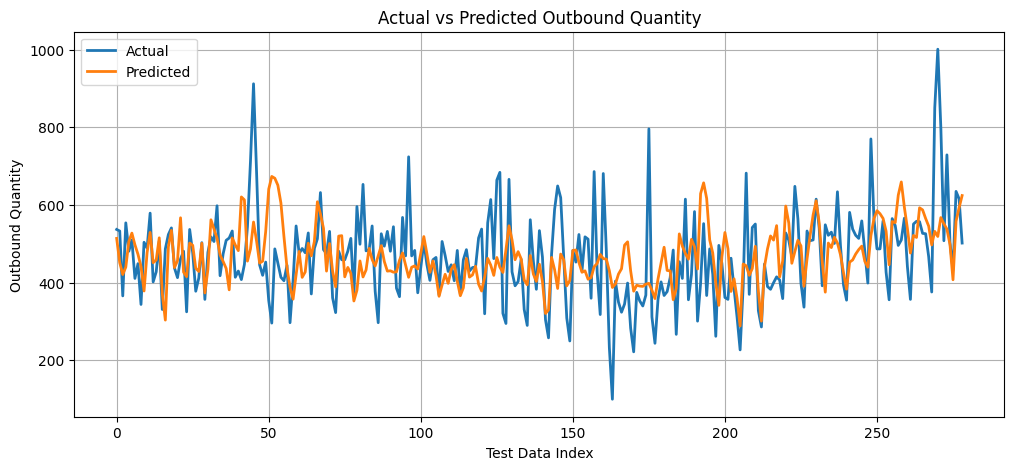

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_real.flatten(), label="Actual", linewidth=2)
plt.plot(pred_real.flatten(), label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Outbound Quantity")
plt.xlabel("Test Data Index")
plt.ylabel("Outbound Quantity")
plt.legend()
plt.grid(True)
plt.show()


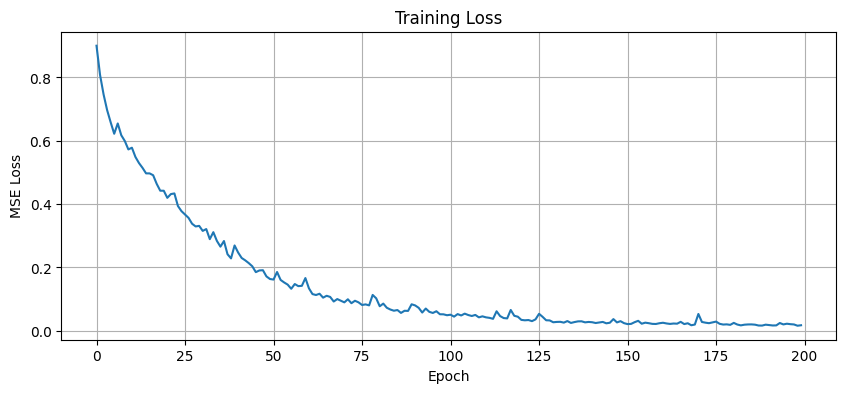

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [21]:
import torch
import joblib
import json
from pathlib import Path

model_dir = Path("backend/ml/outbound_forecast")
model_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), model_dir / "model.pt")
joblib.dump(scaler_X, model_dir / "scaler_X.pkl")
joblib.dump(scaler_y, model_dir / "scaler_y.pkl")

metadata = {
    "features": features,
    "window_size": window_size,
    "input_dim": input_dim,
}

with open(model_dir / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)